Define the default font sizes to make the figures prettier:

In [1]:
import matplotlib.pyplot as plt
from scipy import signal
import numpy as np
from adsp import jaxfilter
from scipy import signal
import jax
import jax.numpy as jnp

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

### 3.6.1 Analytical Examples
Some analytical tools presented so far are employed to characterize two interesting types of adaptive filtering problems. The
problems are also solved with the LMS algorithm.

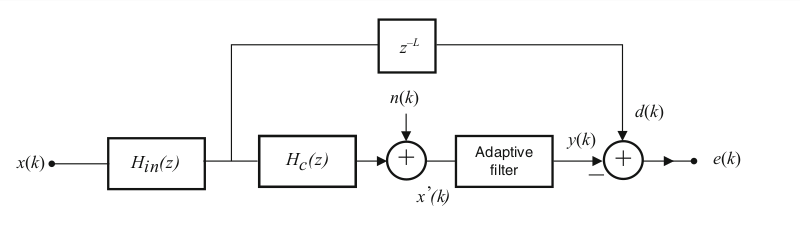

Example 3.1 A Gaussian white-noise sequence (variance $\sigma_{n_1}^2 = 1$) is first colored by

$$
H_{in}(z) = \frac{1}{z - 0.5}
$$

then sent through a communication channel

$$
H_c(z) = \frac{1}{z + 0.8}
$$

and additive channel noise of variance $\sigma_n^2 = 0.1$ is added. The desired signal $d(k)$ is produced by passing the same white noise source through $H_{in}(z)$ and delaying by $L$ samples. We build an adaptive two-tap FIR equalizer (so $M = 2$ taps, i.e., 2 coefficients $w_0, w_1$) and must:

(a) find the best delay $L$,
(b) compute the Wiener solution $w_o$,
(c) choose an appropriate $\mu$ and describe the convergence path,
(d) plot / describe learning curves (single-run and averaged).

#### (a) Choose the best delay $L$

We examine the cross-correlation between the adaptive filter input $x'(k)$ (the channel output) and the desired $d(k)$:

$$
p(i) = E[d(k) \cdot x'(k - i)]
$$

By computing $p(0)$ for small candidate delays $L$ (via contour/residue integration as in the book), the strongest correlation occurs for $L = 1$. In other words, the desired is best aligned with the channel output when delayed by one sample. 

#### (b) Compute the Wiener (optimal) solution

From the book's residue calculations the relevant correlation values (for the two-tap equalizer, i.e. $w = [w_0, w_1]^T$) are:

Cross-correlation vector (for $L = 1$):
$$
p = \begin{bmatrix} p(0) \\ p(1) \end{bmatrix} = \begin{bmatrix} 0.9524 \\ 0.4762 \end{bmatrix}.
$$

Autocorrelation elements of the adaptive filter input $x(k)$ are:
$$
r(0) = 1.6873,
$$
$$
r(1) = -0.7937.
$$

The 2 × 2 input autocorrelation matrix is
$$
R = \begin{bmatrix} 1.6873 & -0.7937 \\ -0.7937 & 1.6873 \end{bmatrix}.
$$

The Wiener (minimum-MSE) solution is
$$
w_o = R^{-1} p.
$$

Carrying out the 2×2 inversion and multiplication (book's values) gives
$$
w_o \approx \begin{bmatrix} 0.8953 \\ 0.7034 \end{bmatrix}.
$$

So the optimal 2-tap equalizer coefficients are approximately
$w_0 = 0.8953$, $w_1 = 0.7034$.

#### (c) Choose $\mu$ and describe convergence path

The book recommends choosing a relatively small step to get a smooth (noisy but stable) path. They used

Step size $\mu$:
$$
\mu = \frac{1}{40 \cdot \text{tr}[R]}.
$$

Here $\text{tr}[R] = 1.6873 + 1.6873 = 3.3746$, so

$$
\mu = \frac{1}{40 \cdot 3.3746} \approx 0.0074.
$$

=== Example 3.1 Channel Equalization ===
Wiener solution: [0.90308092 0.70763155]
R: [[ 1.75344893 -0.87809417]
 [-0.87809417  1.75344893]]
p: [0.96213914 0.44780571]
Final coefficients: [0.92724895 0.72264686]
Final MSE: 0.146644
Final coeff error: 0.014021


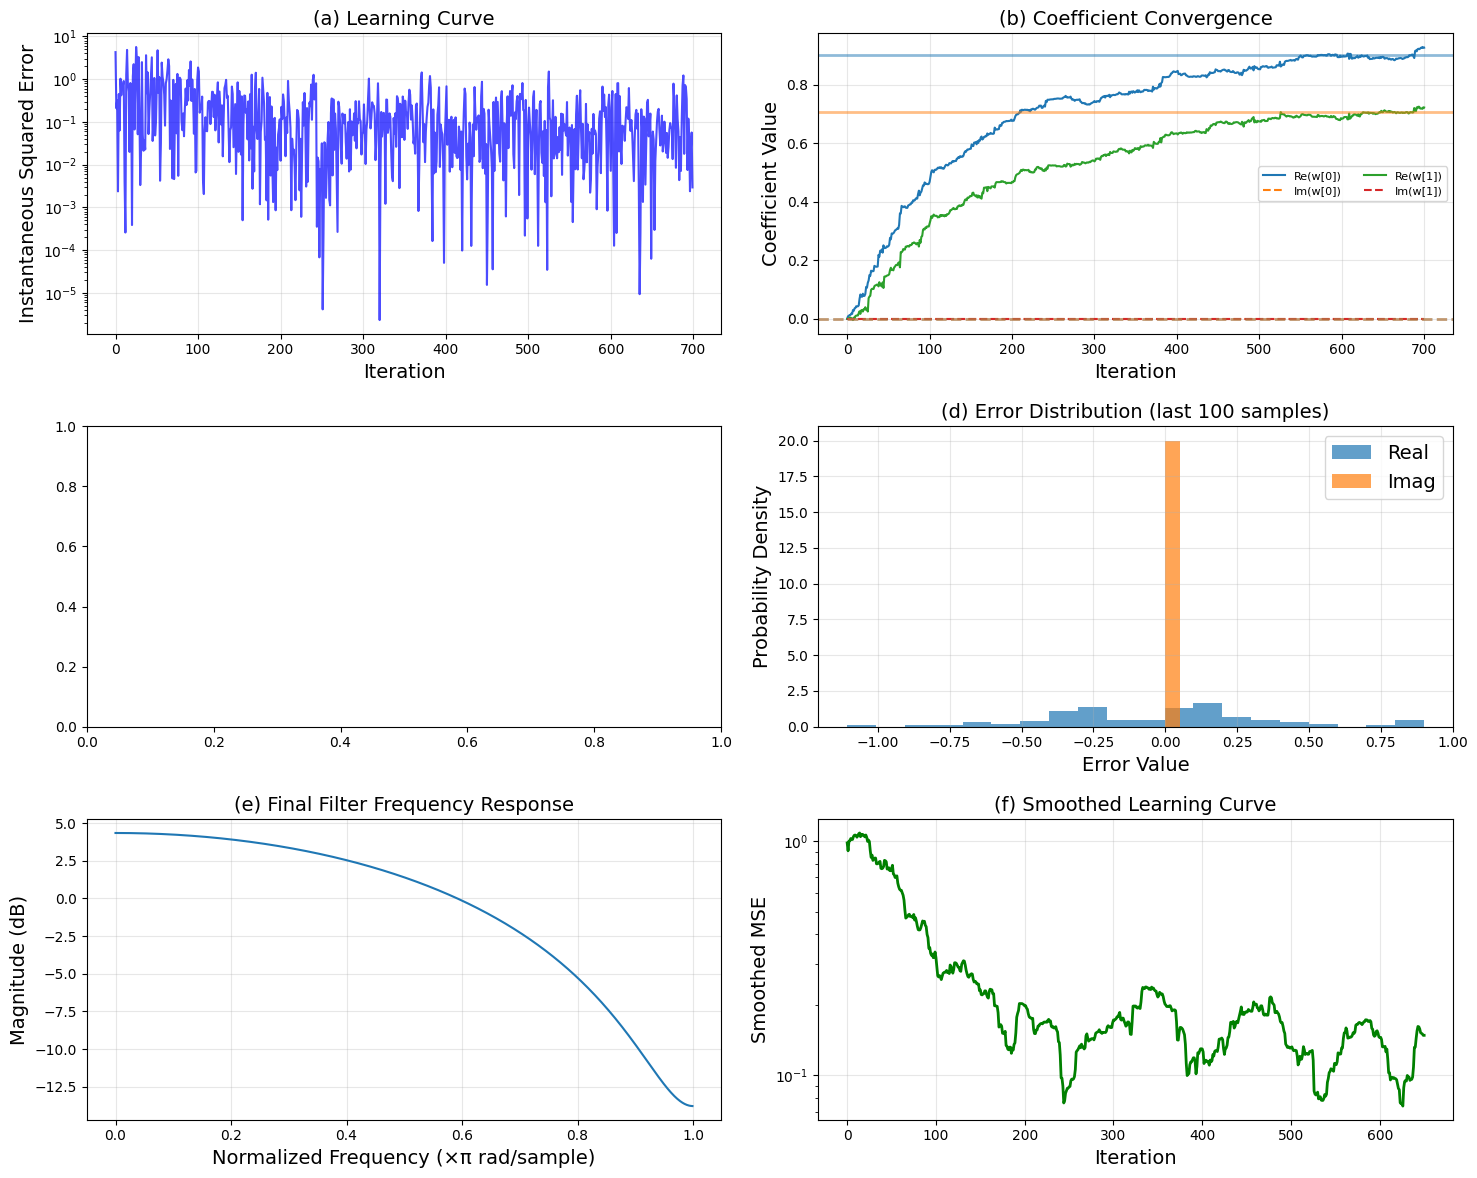

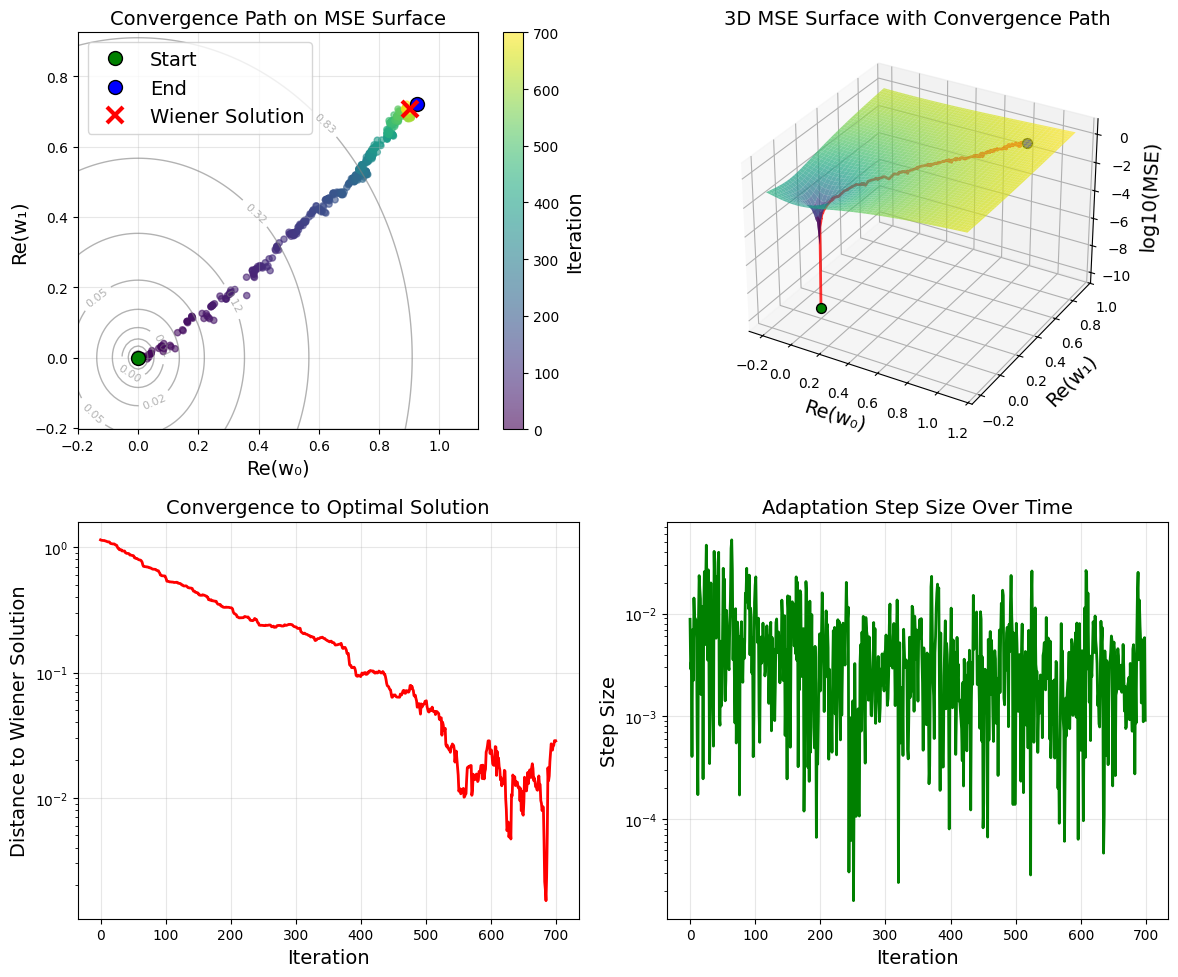


=== CONVERGENCE ANALYSIS ===
Total iterations: 701
Initial coefficients: w0=0.0000, w1=0.0000
Final coefficients: w0=0.9272, w1=0.7226
Wiener solution: w0=0.9031, w1=0.7076
Final distance to Wiener solution: 0.028453
Total path length: 3.5801
Average step size: 0.005114


In [2]:
import jax
import jax.numpy as jnp
import flax.linen as nn
from typing import Optional, Union, Tuple, Dict, Any
# Force JAX to use float64 for better numerical agreement
jax.config.update("jax_enable_x64", True)
_Array = Union[jnp.ndarray]

# --------------------------------------------------
# Signal generator (Example 3.1)
# --------------------------------------------------
def ex3_1_gen_d_x_fn(n_samples: int, key: jax.random.PRNGKey, delay_L: int = 0):
    """Generate input/output signals for Example 3.1 channel equalization."""
    key, subkey1, subkey2 = jax.random.split(key, 3)

    # White Gaussian noise
    u = jax.random.normal(subkey1, (n_samples + 100,), dtype=jnp.float64)

    # H_in(z) = 1 / (1 - 0.5 z^-1)
    def hin_step(carry, u_n):
        y_prev = carry
        y = 0.5 * y_prev + u_n
        return y, y
    _, x_col = jax.lax.scan(hin_step, 0.0, u)

    # H_c(z) = 1 / (1 + 0.8 z^-1)
    def hc_step(carry, x_n):
        y_prev = carry
        y = -0.8 * y_prev + x_n
        return y, y
    _, x_chan = jax.lax.scan(hc_step, 0.0, x_col)

    # Add channel noise
    noise = jax.random.normal(subkey2, (n_samples + 100,), dtype=jnp.float64) * jnp.sqrt(0.1)
    x_final = x_chan + noise

    # Desired signal = delayed colored input
    d = jnp.roll(x_col, delay_L)

    # Remove transients
    return x_final[100:100+n_samples], d[100:100+n_samples]

mu = 1.0 / (40 * 3.3746)  # textbook rule
lms = jaxfilter.LMS(mu=mu, filter_order=1)

eq = jaxfilter.ChannelEqualization(lms, ex3_1_gen_d_x_fn)

w_hist, e_hist, metrics = eq.run(700)
Rinv = jnp.linalg.inv(metrics['R'])
print("=== Example 3.1 Channel Equalization ===")
print(f"Wiener solution: {metrics['wiener_solution']}")
print(f"R: {metrics['R']}")
print(f"p: {metrics['p']}")
print(f"Final coefficients: {metrics['final_coeff']}")
print(f"Final MSE: {metrics['final_mse']:.6f}")
print(f"Final coeff error: {metrics['final_coeff_error']:.6f}")

# Plot single trial results
jaxfilter.plot_results(w_hist, e_hist, metrics, "lms_single_trial")

# Analyze convergence path (for 2D visualization)
if w_hist.shape[1] >= 2:
  jaxfilter.analyze_convergence_path(w_hist, metrics)

#### Example 3.2 — First-Order Adaptive Filter

**Problem Statement**  
Suppose in an adaptive filtering environment, the input signal consists of  

$$
x(k) = \cos(\omega_0 k)
$$

and the desired signal is  

$$
d(k) = \sin(\omega_0 k), \qquad \omega_0 = \frac{2\pi}{M}, \; M=7.
$$

Compute the optimal solution for a **first-order adaptive filter**.

---

Since its a terministic and periodc signals, it's not a random process, so it's highly correlated from its past samples.
Since $x(k)$ is not WSS random but deterministic, the usual definition of autocorrelation $R = E[x x^T]$ does not apply in the probabilistic sense.

Instead, we work with time averages:
$$R_{ij} = \lim_{N \to \infty} \frac{1}{N} \sum_{k=0}^{N-1} x(k - i) x(k - j).$$

Since we're working with a first-order adaptive filter, the regressor is two-dimensional:

$$
\mathbf{x}(k) = \begin{bmatrix} x(k) \\ x(k - 1) \end{bmatrix} = \begin{bmatrix} \cos(\omega_0 k) \\ \cos(\omega_0 (k - 1)) \end{bmatrix}
$$

and the Wiener equations become:

$$
\mathbf{R} = \begin{bmatrix}
\mathbb{E}[\cos^2(\omega_0 k)] & \mathbb{E}[\cos(\omega_0 k) \cos(\omega_0 (k - 1))] \\
\mathbb{E}[\cos(\omega_0 (k - 1)) \cos(\omega_0 k)] & \mathbb{E}[\cos^2(\omega_0 (k - 1))]
\end{bmatrix}
$$

$$
\mathbf{p} = \begin{bmatrix}
\mathbb{E}[\sin(\omega_0 k) \cos(\omega_0 k)] \\
\mathbb{E}[\sin(\omega_0 k) \cos(\omega_0 (k - 1))]
\end{bmatrix}
$$

Then the optimal weight vector is:

$$
\mathbf{w}_0 = \mathbf{R}^{-1} \mathbf{p}.
$$

In the below simulation, I choose step size $$\mu = \frac{1}{40 \cdot \text{tr}[R]}.$$

=== Example 3.2 Channel Equalization ===
Wiener solution: [-0.79747334  1.27904795]
R: [[0.49857143 0.3108542 ]
 [0.3108542  0.49944466]]
p: [-3.33423765e-16  3.90915741e-01]
Final coefficients: [-0.75984379  1.24176342]
Final MSE: 0.000912
Final coeff error: 0.067836


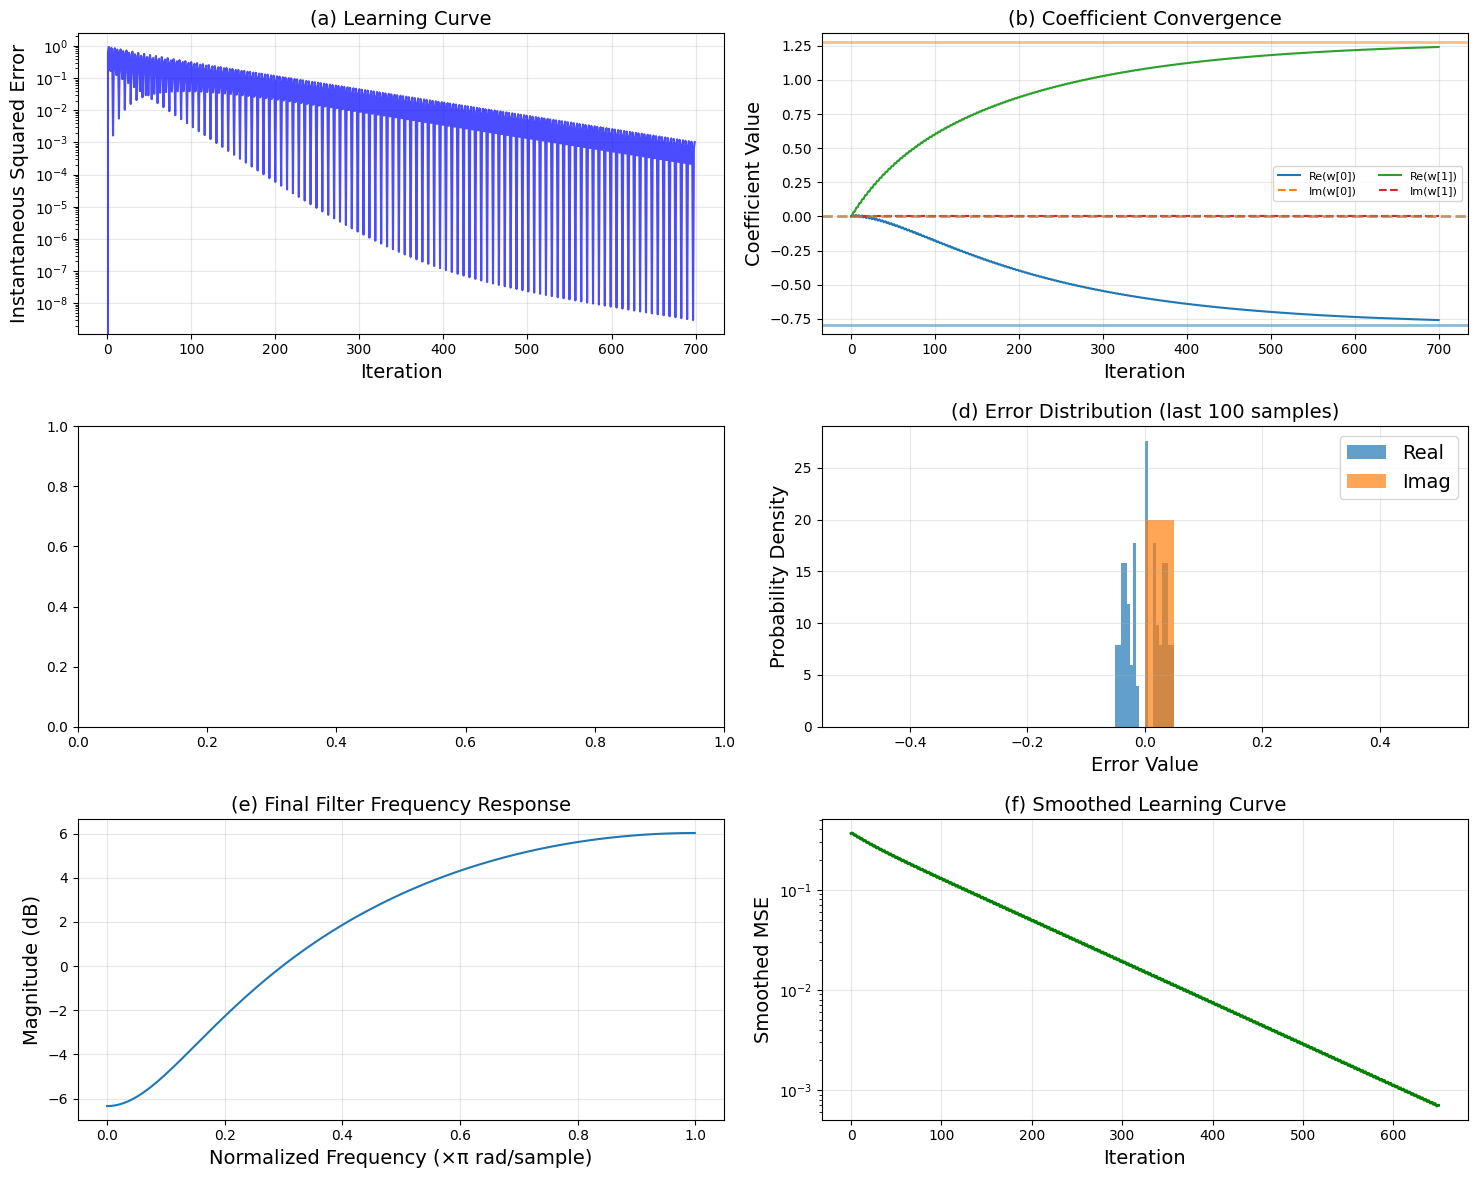

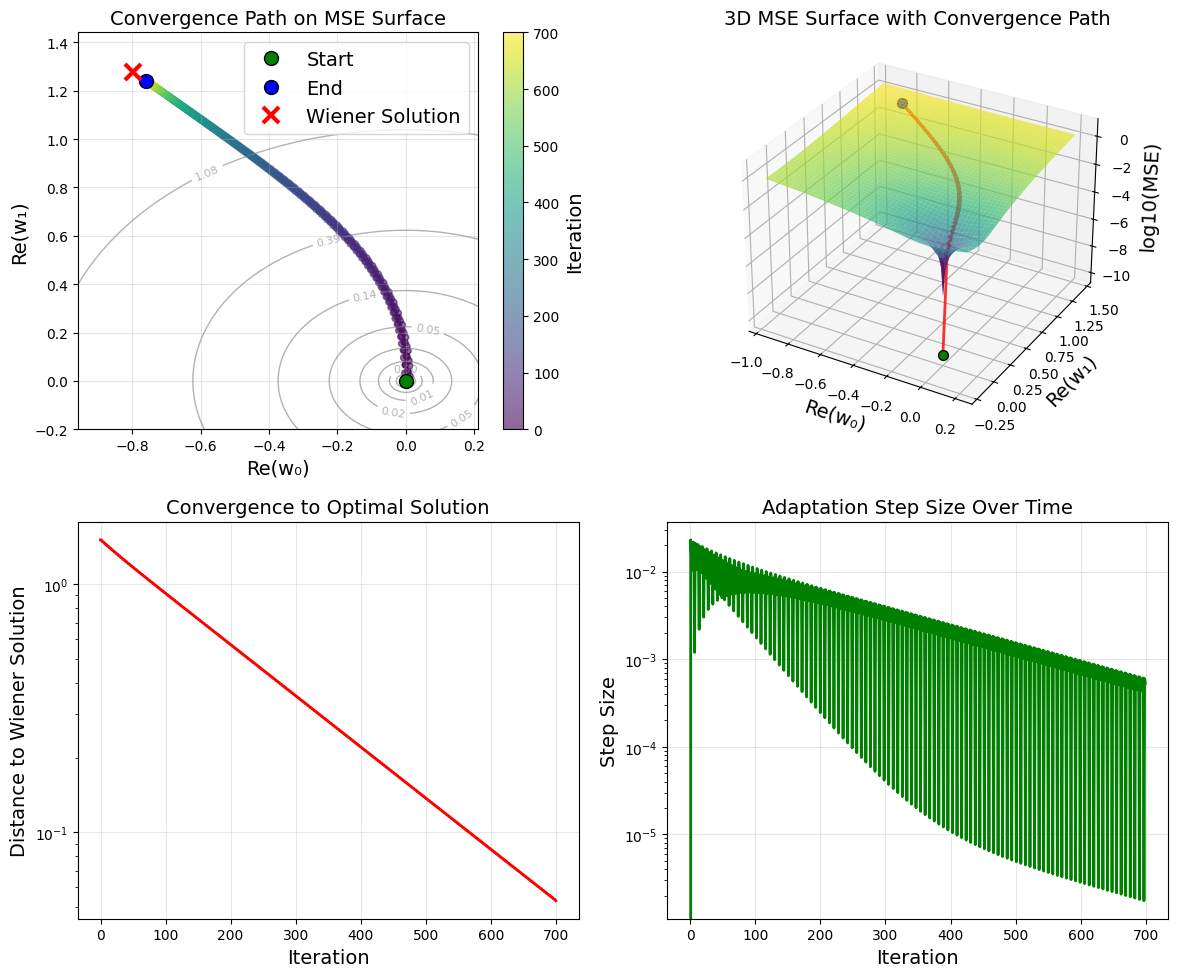


=== CONVERGENCE ANALYSIS ===
Total iterations: 701
Initial coefficients: w0=0.0000, w1=0.0000
Final coefficients: w0=-0.7598, w1=1.2418
Wiener solution: w0=-0.7975, w1=1.2790
Final distance to Wiener solution: 0.052973
Total path length: 2.5886
Average step size: 0.003698


In [7]:
def gen_d_x_fn_example3_2(n_samples: int, key: jax.random.PRNGKey):
    """
    Example 3.2 signal generator: x(k) = cos(ω0 k), d(k) = sin(ω0 k).
    """
    M = 7
    omega0 = 2 * jnp.pi / M
    k = jnp.arange(n_samples, dtype=jnp.float64)

    x = jnp.cos(omega0 * k)
    d = jnp.sin(omega0 * k)

    return x, d
    
def wiener_solution_example3_2(x: jnp.ndarray, d: jnp.ndarray, order: int = 1):
    """
    Example 3.2 Wiener solution using time averages (for deterministic inputs).
    Generalized to filter_order = order (so coefficient length = order + 1).
    
    Args:
      x: input signal (1D array)
      d: desired signal (1D array)
      order: filter order (default 1 → two coefficients)
    
    Returns:
      w_opt: optimal Wiener solution
      R: time-averaged autocorrelation matrix
      p: time-averaged cross-correlation vector
    """
    N = len(x)
    n_coef = order + 1

    if N <= n_coef:
        raise ValueError(f"Need more than {n_coef} samples for time-averaged solution")

    # Build regressor matrix
    # Each row: [x[k], x[k-1], ..., x[k-order]]
    X = jnp.stack([x[order - i:N - i] for i in range(n_coef)], axis=1)
    d_use = d[order:N]  # align desired signal

    # Time-average estimates
    R = (X.conj().T @ X) / (N)
    p = (X.conj().T @ d_use) / (N)

    # Regularization for stability
    R_reg = R + 1e-8 * jnp.eye(n_coef, dtype=x.dtype)
    w_opt = jnp.linalg.solve(R_reg, p)

    return w_opt, R, p


mu = 1.0 / (40 * 1)  # textbook rule (see example 3.3)
lms = jaxfilter.LMS(mu=mu, filter_order=1)
eq = jaxfilter.ChannelEqualization(lms, gen_d_x_fn_example3_2, wiener_sol_fn=wiener_solution_example3_2)

w_hist, e_hist, metrics = eq.run(700)
Rinv = jnp.linalg.inv(metrics['R'])
print("=== Example 3.2 Channel Equalization ===")
print(f"Wiener solution: {metrics['wiener_solution']}")
print(f"R: {metrics['R']}")
print(f"p: {metrics['p']}")
print(f"Final coefficients: {metrics['final_coeff']}")
print(f"Final MSE: {metrics['final_mse']:.6f}")
print(f"Final coeff error: {metrics['final_coeff_error']:.6f}")

# Plot single trial results
jaxfilter.plot_results(w_hist, e_hist, metrics, "lms_single_trial")

# Analyze convergence path (for 2D visualization)
if w_hist.shape[1] >= 2:
  jaxfilter.analyze_convergence_path(w_hist, metrics)


#### Example 3.3
- Input: two-tone signal, $x(k) = cos(ω₀k) + cos(ω₁k)$
- Desired: $d(k) = sin(ω₀k) + sin(ω₁k)$
- Use **time averages** for R and p since signal is deterministic.
- Wiener solution: $wₒ = R^̄{-1}p̄$
- Extends Example 3.2: filter now approximates quadrature relationship for *both* tones.

##### Derivation: Time-averaged Wiener solution (deterministic signals)

**Goal.** For deterministic (non-WSS) inputs we replace ensemble expectations by time averages and obtain the Wiener (least–squares) solution as example 3.2
$$
\overline{\mathbf w} \;\approx\; \overline{\mathbf R}^{-1}\,\overline{\mathbf p},
$$
where
$$
\overline{\mathbf R} \;=\; \overline{\mathbf x(k)\mathbf x^T(k)} 
\;=\; \lim_{N\to\infty}\frac{1}{N}\sum_{k=0}^{N-1}\mathbf x(k)\mathbf x^T(k),
\qquad
\overline{\mathbf p} \;=\; \overline{d(k)\mathbf x(k)}
\;=\; \lim_{N\to\infty}\frac{1}{N}\sum_{k=0}^{N-1}d(k)\,\mathbf x(k).
$$

Below is a self-contained derivation for wiener solution (optimal solution) 

---
##### Derivation of the time-averaged LMS update — equation (3.83)

We use the LMS update in the textbook $2\mu$ form (real-valued signals for simplicity):
$$
\mathbf{w}(k+1) = \mathbf{w}(k) + 2\mu e(k) \mathbf{x}(k),
\qquad
e(k) = d(k) - \mathbf{w}^T(k) \mathbf{x}(k).
$$
Expanding the update gives the algebraically equivalent form
$$
\mathbf{w}(k+1) = \big[\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)\big] \mathbf{w}(k) + 2\mu d(k) \mathbf{x}(k).
\tag{1}
$$

---

##### 1. Define the moving average (over $M$ samples)

For any time sequence $\mathbf{a}(k)$, define the $M$-point (backward) time average
$$
\overline{\mathbf{a}}(k) \equiv \frac{1}{M} \sum_{m=0}^{M-1} \mathbf{a}(k-m).
\tag{2}
$$

(If $\mathbf{a}(k)$ is $M$-periodic, then $\mathbf{a}(k)$ is independent of $k$

---

##### 2. Apply the update to shifted time indices and average

Write the update (1) for the $M$ shifted times $t = k - m$, $m = 0, \dots, M-1$:
$$
\mathbf{w}(k - m + 1) = \big[\mathbf{I} - 2\mu \mathbf{x}(k - m) \mathbf{x}^T(k - m)\big] \mathbf{w}(k - m) + 2\mu d(k - m) \mathbf{x}(k - m).
$$

Average both sides over $m = 0, \dots, M-1$ and use the linearity of the sum:
$$
\frac{1}{M} \sum_{m=0}^{M-1} \mathbf{w}(k - m + 1) = \frac{1}{M} \sum_{m=0}^{M-1} \big[\mathbf{I} - 2\mu \mathbf{x}(k - m) \mathbf{x}^T(k - m)\big] \mathbf{w}(k - m) + \frac{1}{M} \sum_{m=0}^{M-1} 2\mu d(k - m) \mathbf{x}(k - m).
\tag{3}
$$

By definition of the moving average (2), the left-hand side is $\mathbf{w}(k + 1)$. Thus, we obtain the exact averaged-update identity:

$$
\boxed{
\overline{\mathbf{w}}(k + 1) = \frac{1}{M} \sum_{m=0}^{M-1} \big[\mathbf{I} - 2\mu \mathbf{x}(k - m) \mathbf{x}^T(k - m)\big] \mathbf{w}(k - m) + \frac{1}{M} \sum_{m=0}^{M-1} 2\mu d(k - m) \mathbf{x}(k - m)
}
\tag{3.83}
$$

Equivalently, using the overline shorthand,
$$
\boxed{
\overline{\mathbf{w}}(k + 1) = \overline{\big[\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)\big] \mathbf{w}(k)} + \overline{2\mu d(k) \mathbf{x}(k)}
}
\tag{3.83'}
$$

This is an **exact** identity (no approximations yet): it simply averages the shifted, exact updates.

---

##### 3. Usual approximation (decoupling / slow-variation)

To make (3.83) useful, we often assume the filter coefficients vary **slowly** over the averaging window (small step size $\mu$, so that $\mathbf{w}(k - m) \approx \overline{\mathbf{w}}(k)$ for $m = 0, \dots, M-1$. Under this **slow-variation** (or quasi-stationarity) assumption, we can move $\mathbf{w}$ outside the time-average of the multiplicative term:

$$
\overline{\big[\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)\big] \mathbf{w}(k)} \approx \Big(\overline{\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)}\Big) \overline{\mathbf{w}}(k).
$$

Because $\mathbf{I}$ is constant and the averaging operator is linear,
$$
\overline{\mathbf{I} - 2\mu \mathbf{x}(k) \mathbf{x}^T(k)} = \mathbf{I} - 2\mu \overline{\mathbf{x}(k) \mathbf{x}^T(k)} = \mathbf{I} - 2\mu \overline{\mathbf{R}},
$$
where we define the time-averaged autocorrelation matrix
$$
\overline{\mathbf{R}} = \overline{\mathbf{x}(k) \mathbf{x}^T(k)}.
$$

Similarly,
$$
\overline{2\mu d(k) \mathbf{x}(k)} = 2\mu \overline{d(k) \mathbf{x}(k)} \equiv 2\mu \overline{\mathbf{p}}.
$$

Thus, under the slow-variation approximation, (3.83) becomes
$$
\overline{\mathbf{w}}(k + 1) \approx \big(\mathbf{I} - 2\mu \overline{\mathbf{R}}\big) \overline{\mathbf{w}}(k) + 2\mu \overline{\mathbf{p}}.
\tag{4}
$$

---

##### 4. Steady state and the time-average Wiener solution

At steady state (or for fixed point of the averaged recursion), set $\mathbf{w}(k + 1) = \mathbf{w}(k) = \mathbf{w}$ in (4):
$$
\overline{\mathbf{w}} = \big(\mathbf{I} - 2\mu \overline{\mathbf{R}}\big) \overline{\mathbf{w}} + 2\mu \overline{\mathbf{p}}.
$$

Rearrange:
$$
2\mu \overline{\mathbf{R}} \overline{\mathbf{w}} = 2\mu \overline{\mathbf{p}} \quad \Longrightarrow \quad \overline{\mathbf{R}} \overline{\mathbf{w}} = \overline{\mathbf{p}}.
$$

Provided $\overline{\mathbf{R}}$ is invertible,
$$
\boxed{\quad \overline{\mathbf{w}} = \overline{\mathbf{R}}^{-1} \overline{\mathbf{p}} \quad}
$$
which is the **time-averaged Wiener (least-squares) solution** used for deterministic or periodic inputs.

---

##### 5. Remarks and assumptions

- (3.83) is exact (no approximations); it is simply the average of the exact single-step updates.  
- The step from (3.83) to (4) **requires** the quasi-stationarity/slow-variation assumption (or equivalently that the coefficient vector is almost constant over the averaging window). This is typically justified when $\mu$ is small.  
- If $x(k)$ is periodic with period $M$, then $\overline{\mathbf{R}}$ and $\overline{\mathbf{p}}$ are simply the averages over one period and are time invariant.  
- If $\overline{\mathbf{R}}$ is singular (e.g., single-tone narrowband with filter length large), the inverse is replaced by a pseudo-inverse, and the solution is not unique.

---

**Conclusion.** (3.83) is obtained by averaging the per-time LMS updates. Under slow weight variation, we factor averages and obtain the averaged linear recursion (4), whose fixed point is the time-average Wiener solution $\overline{\mathbf{w}} = \overline{\mathbf{R}}^{-1} \overline{\mathbf{p}}.$


### 3.5 & 3.6.3 Channel Equalization Simulations
Example 3.6 Perform the system idetification problem 